# HydroLAKES — raw vs STAC folder vs cloud

Checks that the HydroLAKES polygons are the same in the three places they live:

1. **Raw**: `P:\...\Data_Vivian\HydroLAKES_polys_v10.shp` (original shapefile)
2. **STAC folder**: `P:\...\Data_Vivian\stac\hydrolakes\parquet\hydrolakes.parquet` (GeoParquet produced by `notebooks/18_hydrolakes.ipynb`)
3. **Cloud**: the GeoParquet found through the public STAC catalog (`gca-stac-7`, collection `hydrolakes`)

The 1.4 million polygons are too many to draw three times, so the check is split in two:

- **Whole world, attributes only:** all attribute columns are compared (rows, values, total area) and the lake pour points are plotted.
- **One region, geometries:** the polygons inside `BBOX` are read from each source, plotted side by side and compared geometry by geometry.

Environment: `environment_exploration.yml` (Miniforge). Reading the raw shapefile attributes and the cloud columns takes a few minutes.

In [4]:
from pathlib import Path
from posixpath import join as urljoin

import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import pyogrio
import pystac_client

## 1) Locations

In [5]:
data_vivian = Path(r"P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian")
raw_path = data_vivian / "HydroLAKES_polys_v10.shp"
stac_folder_path = data_vivian / "stac" / "hydrolakes" / "parquet" / "hydrolakes.parquet"

gcs_protocol = "https://storage.googleapis.com"
catalog_url = urljoin(gcs_protocol, "gca-data-public", "gca", "gca-stac-7", "catalog.json")
collection_id = "hydrolakes"

# Region used for the geometry check (west, south, east, north): Lake Nasser, Egypt/Sudan
BBOX = (30.0, 20.0, 34.0, 24.5)

for p in (raw_path, stac_folder_path):
    print(p.is_file(), p)

True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\HydroLAKES_polys_v10.shp
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\stac\hydrolakes\parquet\hydrolakes.parquet


## 2) Find the data through the STAC catalog

In [6]:
catalog = pystac_client.Client.open(catalog_url)
collection = catalog.get_collection(collection_id)
if collection is None:
    raise LookupError(f"Collection {collection_id} not found in {catalog_url}")

items = list(collection.get_items())
print("Collection:", collection.id, "|", collection.title)
print("Items:", [i.id for i in items])

item = items[0]
cloud_href = item.assets["data"].href
print("Cloud GeoParquet:", cloud_href)
print("Item bbox:", item.bbox)
print("table:row_count:", item.properties.get("table:row_count"))
print("Item properties:", list(item.properties))

# Attribute columns from the parquet schema (no data is read), independent of the item's table:columns
attr_cols = [n for n in pq.read_schema(stac_folder_path).names if n not in ("geometry", "bbox")]
item_cols = [c["name"] for c in item.properties.get("table:columns", [])]
if item_cols:
    print("item table:columns match the parquet schema:", set(item_cols) - {"bbox"} == set(attr_cols) | {"geometry"})
else:
    print("WARNING: the cloud item has no table:columns (re-run scripts/18_hydrolakes.ipynb steps 4-7)")
print("Attribute columns:", attr_cols)

Collection: hydrolakes | HydroLAKES
Items: ['hydrolakes']
Cloud GeoParquet: https://storage.googleapis.com/gca-data-public/gca/hydrolakes/hydrolakes.parquet
Item bbox: [-180.0, -55.865139, 180.0, 83.575951]
table:row_count: 1427688
Item properties: ['title', 'description', 'table:row_count', 'table:columns', 'deltares:item_key', 'created', 'datetime', 'proj:code']
item table:columns match the parquet schema: True
Attribute columns: ['Hylak_id', 'Lake_name', 'Country', 'Continent', 'Poly_src', 'Lake_type', 'Grand_id', 'Lake_area', 'Shore_len', 'Shore_dev', 'Vol_total', 'Vol_res', 'Vol_src', 'Depth_avg', 'Dis_avg', 'Res_time', 'Elevation', 'Slope_100', 'Wshd_area', 'Pour_long', 'Pour_lat']


## 3) Read the attributes of the whole world

Geometries are skipped; only the attribute columns are read from the three sources.

In [7]:
def tidy(df: pd.DataFrame) -> pd.DataFrame:
    return df[attr_cols].sort_values("Hylak_id").reset_index(drop=True)


tables = {}
tables["raw (P:)"] = tidy(pyogrio.read_dataframe(raw_path, read_geometry=False))
tables["stac folder (P:)"] = tidy(pq.read_table(stac_folder_path, columns=attr_cols).to_pandas())
with fsspec.open(cloud_href).open() as f:
    tables["cloud (catalog)"] = tidy(pq.read_table(f, columns=attr_cols).to_pandas())

pd.DataFrame(
    {
        name: {
            "rows": len(df),
            "unique Hylak_id": df["Hylak_id"].is_unique,
            "total Lake_area (km2)": round(df["Lake_area"].sum(), 2),
            "total Vol_total (million m3)": round(df["Vol_total"].sum(), 2),
        }
        for name, df in tables.items()
    }
).T

,rows,unique Hylak_id,total Lake_area (km2),total Vol_total (million m3)
raw (P:),1427688,True,2926722.77,187866131.33
stac folder (P:),1427688,True,2926722.77,187866131.33
cloud (catalog),1427688,True,2926722.77,187866131.33


## 4) Plot the lake pour points (whole world)

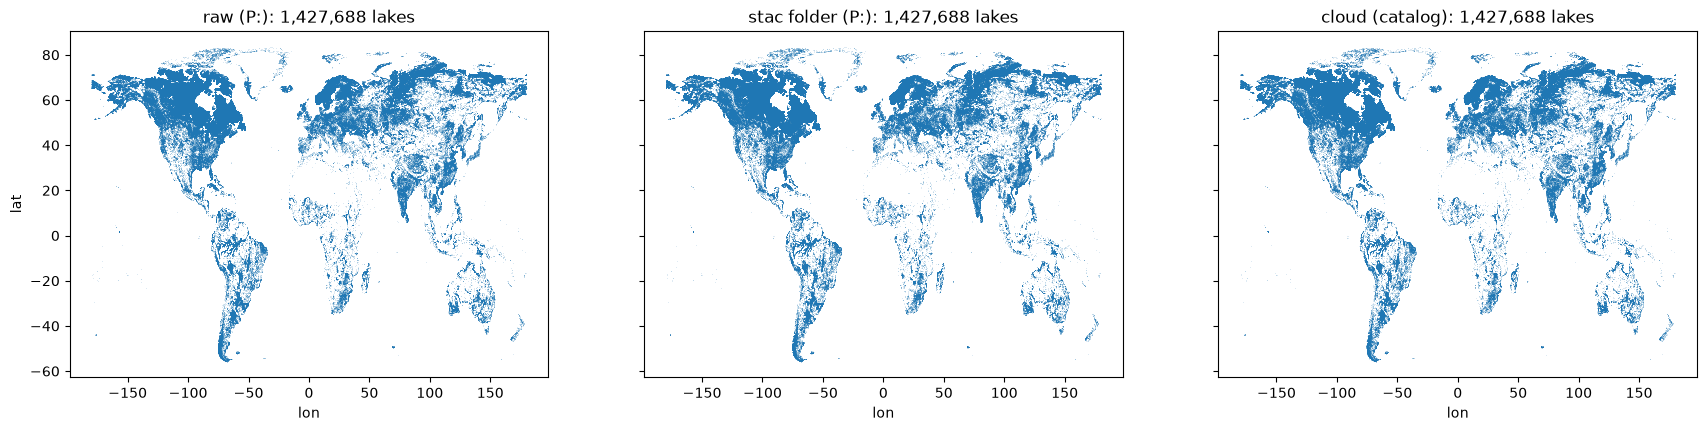

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 4.5), sharex=True, sharey=True)
for ax, (name, df) in zip(axes, tables.items()):
    ax.scatter(df["Pour_long"], df["Pour_lat"], s=0.05, c="tab:blue", linewidths=0, rasterized=True)
    ax.set_title(f"{name}: {len(df):,} lakes")
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.show()

## 5) Compare the attributes

In [9]:
names = list(tables)
ref = names[0]
attr_results = []
for other in names[1:]:
    same_shape = tables[ref].shape == tables[other].shape
    identical = same_shape and tables[ref].equals(tables[other])
    n_diff = int((tables[ref].ne(tables[other]) & ~(tables[ref].isna() & tables[other].isna())).to_numpy().sum()) if same_shape else None
    attr_results.append({"comparison": f"{ref} vs {other}", "same shape": same_shape, "different values": n_diff, "identical": identical})
display(pd.DataFrame(attr_results))

if all(r["identical"] for r in attr_results):
    print("OK: raw, stac folder and cloud have exactly the same attribute table.")
else:
    print("MISMATCH: see the table above.")

,comparison,same shape,different values,identical
0,raw (P:) vs stac folder (P:),True,0,True
1,raw (P:) vs cloud (catalog),True,0,True


OK: raw, stac folder and cloud have exactly the same attribute table.


## 6) Read the polygons inside `BBOX`

Only the features that intersect `BBOX` are read: the shapefile through its spatial index, the GeoParquet files through the `bbox` covering column.

In [10]:
regions = {}
regions["raw (P:)"] = gpd.read_file(raw_path, bbox=BBOX, engine="pyogrio")
regions["stac folder (P:)"] = gpd.read_parquet(stac_folder_path, bbox=BBOX)
regions["cloud (catalog)"] = gpd.read_parquet(cloud_href, bbox=BBOX, filesystem=fsspec.filesystem("https"))

# Drop the covering column and put the rows in the same order
regions = {
    name: gdf.drop(columns="bbox", errors="ignore").sort_values("Hylak_id").reset_index(drop=True)
    for name, gdf in regions.items()
}
for name, gdf in regions.items():
    print(f"{name}: {len(gdf)} lakes, crs={gdf.crs.to_string()}")

raw (P:): 18 lakes, crs=EPSG:4326
stac folder (P:): 18 lakes, crs=EPSG:4326
cloud (catalog): 18 lakes, crs=EPSG:4326


## 7) Plot the polygons

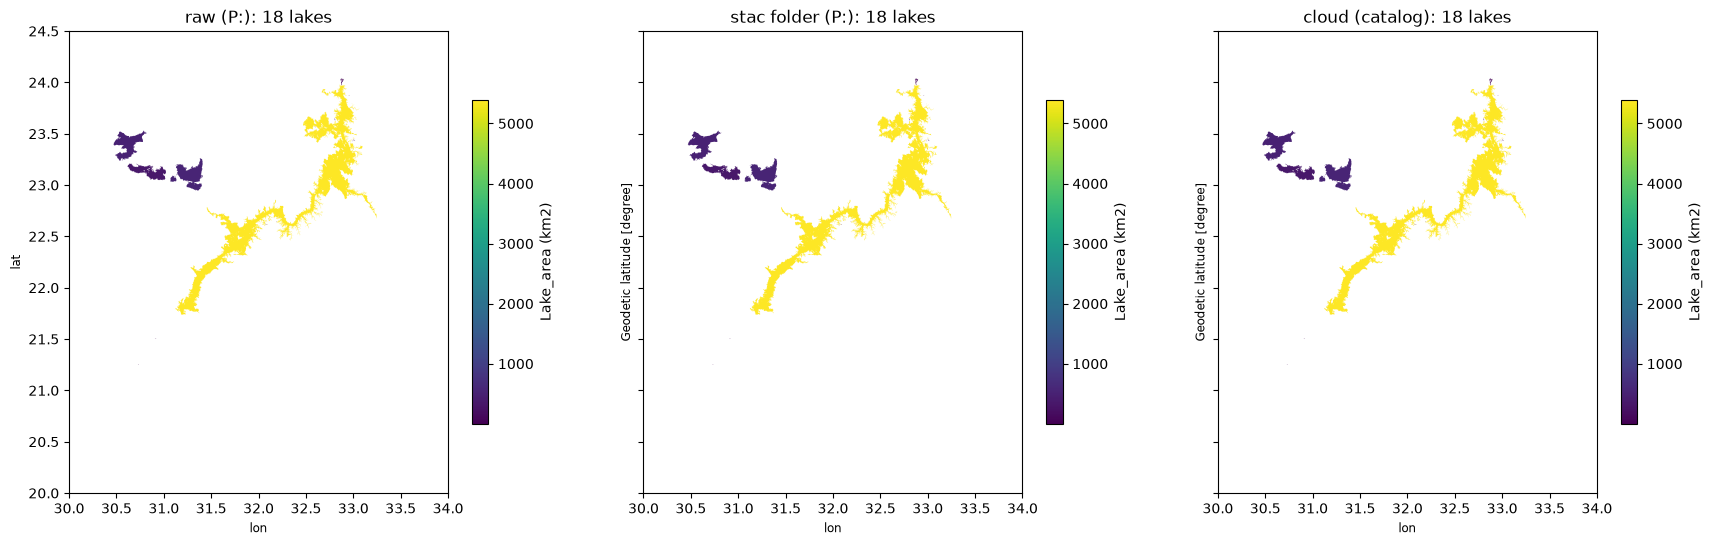

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for ax, (name, gdf) in zip(axes, regions.items()):
    gdf.plot(ax=ax, column="Lake_area", cmap="viridis", legend=True, legend_kwds={"label": "Lake_area (km2)", "shrink": 0.7})
    ax.set_xlim(BBOX[0], BBOX[2])
    ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_title(f"{name}: {len(gdf)} lakes")
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.show()

## 8) Compare the geometries

In [12]:
ref = list(regions)[0]
geom_results = []
for other in list(regions)[1:]:
    same_ids = regions[ref]["Hylak_id"].equals(regions[other]["Hylak_id"])
    n_diff = int((~regions[ref].geometry.geom_equals_exact(regions[other].geometry, tolerance=0)).sum()) if same_ids else None
    geom_results.append({
        "comparison": f"{ref} vs {other}",
        "same lakes": same_ids,
        "same CRS": regions[ref].crs == regions[other].crs,
        "different geometries": n_diff,
        "identical": same_ids and n_diff == 0,
    })
display(pd.DataFrame(geom_results))

if all(r["identical"] for r in geom_results):
    print("OK: raw, stac folder and cloud contain exactly the same polygons in BBOX.")
else:
    print("MISMATCH: see the table above.")

,comparison,same lakes,same CRS,different geometries,identical
0,raw (P:) vs stac folder (P:),True,True,0,True
1,raw (P:) vs cloud (catalog),True,True,0,True


OK: raw, stac folder and cloud contain exactly the same polygons in BBOX.
